# Telco Customer Churn — Capstone Project (Machine Learning)

This notebook explores the Telco Customer Churn dataset, preprocesses the data, visualises
key relationships, and builds **logistic regression** and **random forest** models to predict
customer churn. Feature importance and model evaluation metrics (confusion matrix, precision,
recall, OOB error) are used to compare the two models.


## 1. Import libraries

In [86]:
# Import libraries for data analysis
import pandas as pd
import numpy as np


# Import libraries for data visualisation
import matplotlib.pyplot as plt
import seaborn as sns


# Import libraries for machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay,
)

# Make plots look consistent
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Ensure all output is easy to read
pd.set_option("display.max_columns", None)

## 2. Load the dataset

In [87]:
# Load the Telco Customer Churn dataset
DATA_PATH = "Telco-Customer-Churn.csv"

telecom_cust = pd.read_csv(DATA_PATH)

## 3. Data inspection phase

Before doing any preprocessing, we take a first look at the structure of the dataset:
its first rows, the column names, and the data types of each column.

In [88]:
# Display the first 10 rows
telecom_cust.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [89]:
# Display the column names
print("Dataset Columns:")
print(telecom_cust.columns.tolist())

Dataset Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [90]:
# Display the data types of each column
print("Data Types:")
print(telecom_cust.dtypes)

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


**Note:** `TotalCharges` is currently stored as an `object` (text) column rather than a
numeric one, even though it represents a monetary value. This needs to be corrected during
preprocessing.

## 4. Data preprocessing phase

In this phase we clean the data and prepare it so it is ready for modelling:

- Convert `TotalCharges` to a numeric type.
- Remove rows with missing values.
- Drop the `customerID` column (it's a unique identifier with no predictive value).
- Convert the `Churn` target column to binary numeric values.
- Convert categorical variables into dummy variables, carefully avoiding the dummy
  variable trap.

In [91]:
# Convert the "TotalCharges" column to the numeric data type.
# errors="coerce" turns any non-numeric entries (e.g. blank strings) into NaN
# so that we can identify and remove them in the next step.
telecom_cust["TotalCharges"] = pd.to_numeric(
    telecom_cust["TotalCharges"],
    errors="coerce"
)
#show the number of missing values in the "TotalCharges" column
print(f"Number of missing values in 'TotalCharges' after conversion: "
      f"{telecom_cust['TotalCharges'].isnull().sum()}")
# Check the data type
print(f"Data type of 'TotalCharges' after conversion: {telecom_cust['TotalCharges'].dtype}")

Number of missing values in 'TotalCharges' after conversion: 11
Data type of 'TotalCharges' after conversion: float64


In [92]:
# Remove rows with missing values
rows_before = telecom_cust.shape[0]

telecom_cust = telecom_cust.dropna()

rows_after = telecom_cust.shape[0]

print(f"Removed {rows_before - rows_after} rows containing missing values.")
print(f"Dataset shape after removing missing values: {telecom_cust.shape}")

Removed 11 rows containing missing values.
Dataset shape after removing missing values: (7032, 21)


In [93]:
# Remove the "customerID" column from the dataset.
# It is a unique identifier for each customer and carries no predictive signal.
telecom_cust = telecom_cust.drop(columns=["customerID"])
print("'customerID' column removed.")
print(f"Remaining columns: {telecom_cust.shape[1]}")


'customerID' column removed.
Remaining columns: 20


In [94]:
# Convert the "Churn" column to binary numeric values: "Yes" -> 1, "No" -> 0
telecom_cust["Churn"] = telecom_cust["Churn"].map({"Yes": 1, "No": 0})

print("'Churn' value counts after conversion:")
telecom_cust["Churn"].value_counts()

'Churn' value counts after conversion:


Churn
0    5163
1    1869
Name: count, dtype: int64

### Converting categorical variables to dummy variables

To avoid the **dummy variable trap** (perfect multicollinearity between dummy columns), we use
`drop_first=True` when one-hot encoding. This drops one category per categorical feature,
using it as an implicit "baseline" that the model can infer from the other dummies being 0.

In [95]:
# Identify categorical (object-type) columns to convert into dummy variables.
# "SeniorCitizen" is already numeric (0/1) so it does not need encoding.
categorical_columns = telecom_cust.select_dtypes(include="object").columns.tolist()
print(f"Categorical columns to encode: {categorical_columns}")

# Convert all categorical variables into dummy variables, dropping the first
# category of each to avoid the dummy variable trap (multicollinearity).
telecom_cust_dummies = pd.get_dummies(
    telecom_cust, columns=categorical_columns, drop_first=True, dtype=int
)

print(f"\nShape before encoding: {telecom_cust.shape}")
print(f"Shape after encoding:  {telecom_cust_dummies.shape}")

# Display the first 5 rows of the encoded dataset
telecom_cust_dummies.head()

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Shape before encoding: (7032, 20)
Shape after encoding:  (7032, 31)


C:\Users\kkhut\AppData\Local\Temp\ipykernel_14124\2301969783.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = telecom_cust.select_dtypes(include="object").columns.tolist()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0


## 5. Data visualisation phase

With clean, encoded data available, we now explore relationships between features and the
target variable `Churn`.

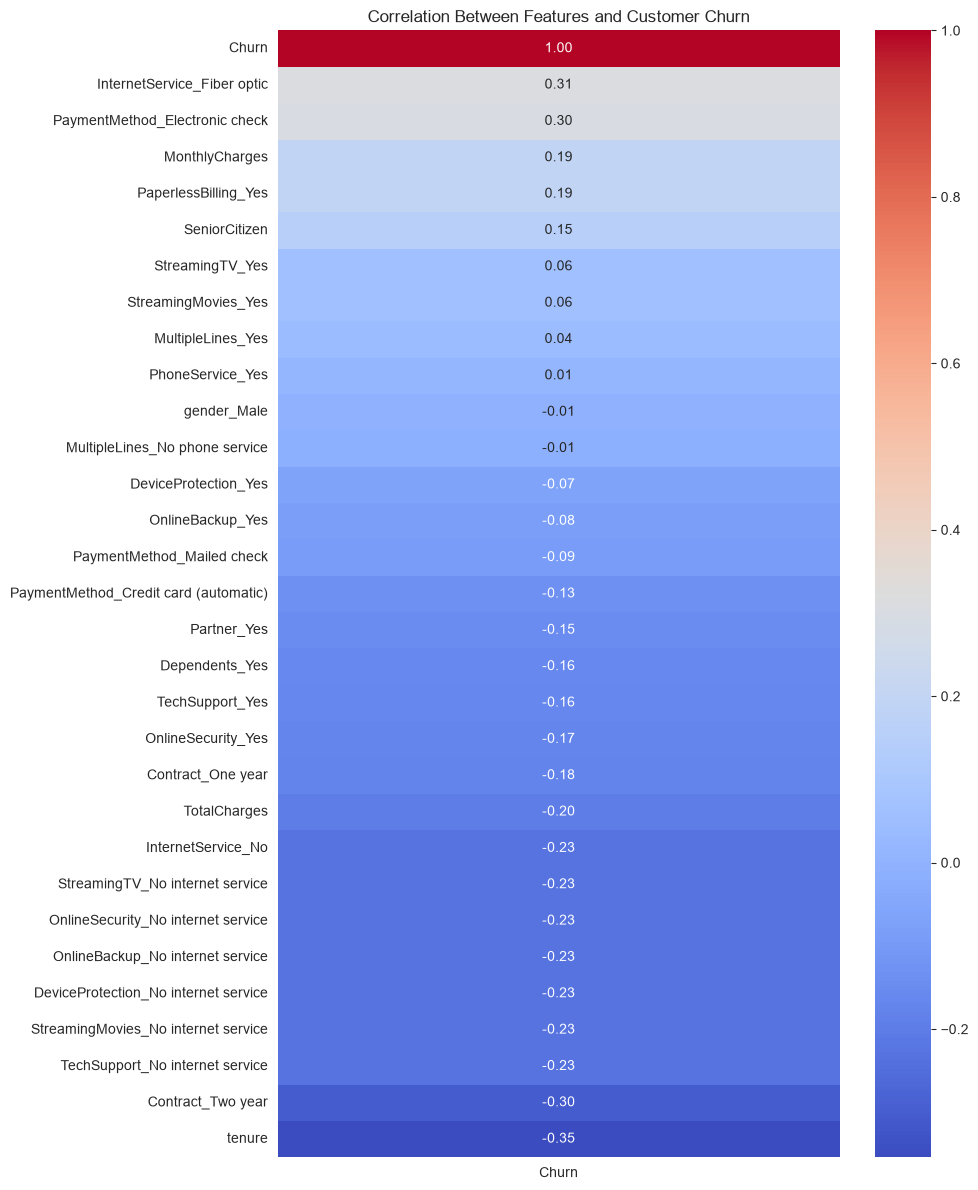

In [96]:
# Create a correlation plot to visualise the correlation between features
# and the target variable "Churn".
# Create a correlation plot for features and Churn
correlation = telecom_cust_dummies.corr()

plt.figure(figsize=(10, 12))
sns.heatmap(
    correlation[["Churn"]].sort_values(by="Churn", ascending=False),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Features and Customer Churn")
plt.tight_layout()
plt.show()

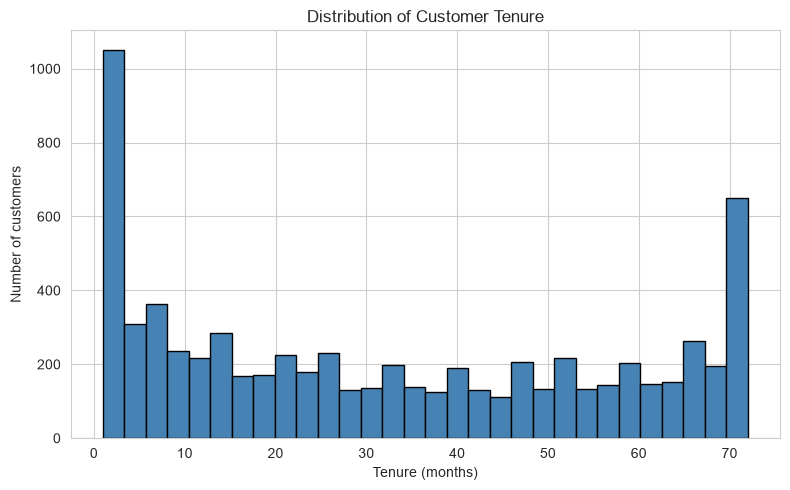

In [97]:
# Create a histogram of the "tenure" column.
plt.figure(figsize=(8, 5))
plt.hist(telecom_cust["tenure"], bins=30, color="steelblue", edgecolor="black")
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()


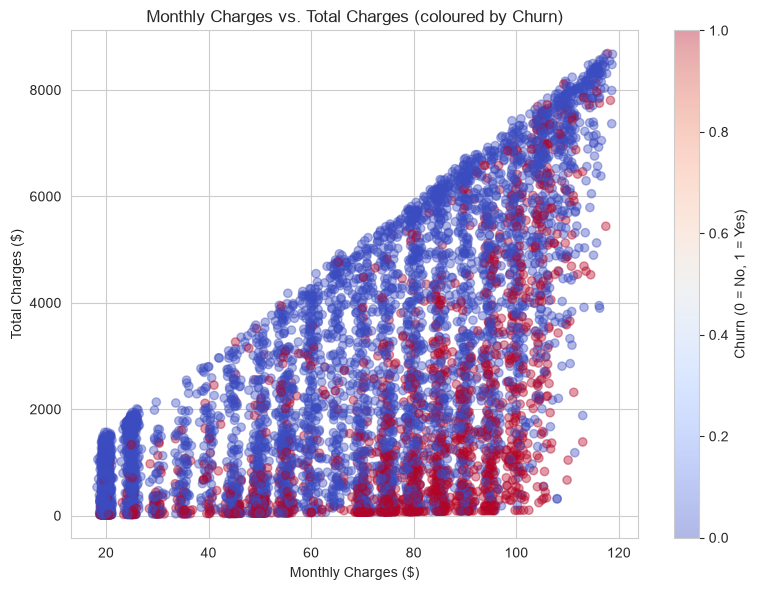

In [98]:
# Create a scatter plot of "MonthlyCharges" vs. "TotalCharges".
plt.figure(figsize=(8, 6))
plt.scatter(
    telecom_cust["MonthlyCharges"],
    telecom_cust["TotalCharges"],
    alpha=0.4,
    c=telecom_cust["Churn"],
    cmap="coolwarm",
)
plt.title("Monthly Charges vs. Total Charges (coloured by Churn)")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Total Charges ($)")
plt.colorbar(label="Churn (0 = No, 1 = Yes)")
plt.tight_layout()
plt.show()

C:\Users\kkhut\AppData\Local\Temp\ipykernel_14124\2269203161.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y="tenure", data=telecom_cust, palette="Set2")


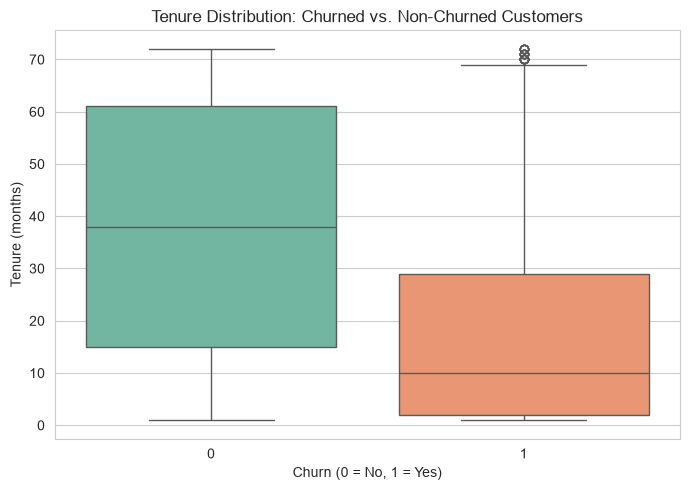

In [99]:
# Create a box plot to compare "tenure" for churned and non-churned customers.
plt.figure(figsize=(7, 5))
sns.boxplot(x="Churn", y="tenure", data=telecom_cust, palette="Set2")
plt.title("Tenure Distribution: Churned vs. Non-Churned Customers")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Tenure (months)")
plt.tight_layout()
plt.show()

**Observations:**
- Customers with shorter tenure and month-to-month contracts tend to correlate more strongly
  with churn.
- Customers who churn typically have lower tenure (visible in the box plot), suggesting that
  newer customers are more likely to leave.
- `MonthlyCharges` and `TotalCharges` are positively related, as expected, since total charges
  accumulate over tenure.

## 6. Preparations for ML training

We scale all features to a range of 0 to 1 using min-max scaling, then split the data into
training and test sets.

In [100]:
# Separate the features and target variable
X = telecom_cust_dummies.drop(columns=["Churn"])
y = telecom_cust_dummies["Churn"]

# Display the shapes of the features and target variable
print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, random_state=42)

# Display the sizes of the training and test sets
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size:     {X_test.shape[0]} rows")

Features shape: (7032, 30)
Target shape: (7032,)
Training set size: 5274 rows
Test set size:     1758 rows


In [101]:
# Create a Min-Max scaler
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform both datasets
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# Display the first 5 rows of the scaled training data
print("Feature scaling complete.")
print("Example of scaled training values:")
X_train_scaled.head()

Feature scaling complete.
Example of scaled training values:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3166,0.0,0.183099,0.304434,0.074493,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4333,0.0,0.422535,0.720478,0.335901,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1927,0.0,0.647887,0.887892,0.588522,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2315,0.0,0.478873,0.550075,0.304900,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
858,0.0,0.915493,0.705032,0.678489,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## 7. Logistic regression model

In [102]:
# Create the Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model using the training data
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [103]:
# Make predictions on the test data
log_reg_predictions = logistic_model.predict(X_test_scaled)

print("Logistic Regression predictions completed.")

Logistic Regression predictions completed.


In [104]:
# Calculate Logistic Regression accuracy
log_reg_accuracy = accuracy_score(y_test, log_reg_predictions)

print(f"Logistic Regression Accuracy: {log_reg_accuracy:.4f}")

Logistic Regression Accuracy: 0.7912


## 8. Random forest model

We create a random forest classifier with the specified hyperparameters:
- `n_estimators=2000` — 2000 decision trees.
- `oob_score=True` — enable out-of-bag error estimation.
- `max_features="sqrt"` — number of features considered at each split.
- `max_leaf_nodes=50` — restrict tree complexity.
- `bootstrap=True` — enable bootstrapping.

In [105]:
# Create a random forest classifier with the required hyperparameters.
rf_model = RandomForestClassifier(
    n_estimators=2000,
    oob_score=True,
    max_features="sqrt",
    max_leaf_nodes=50,
    bootstrap=True,
    random_state=42,
    n_jobs=-1,  # use all available CPU cores to speed up training
)

In [106]:
# Fit the model.
rf_model.fit(X_train_scaled, y_train)
print("Random forest model trained successfully.")


Random forest model trained successfully.


In [107]:
# Make predictions on the new test data.
rf_predictions = rf_model.predict(X_test_scaled)

In [108]:
# Calculate and print the accuracy score of the random forest classifier.
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.7935


In [109]:
# Calculate and print the OOB error estimation.
oob_error = 1 - rf_model.oob_score_
print(f"Random Forest OOB Score:  {rf_model.oob_score_:.4f}")
print(f"Random Forest OOB Error:  {oob_error:.4f}")

Random Forest OOB Score:  0.8072
Random Forest OOB Error:  0.1928


**OOB error interpretation:** The out-of-bag (OOB) error estimates how well the random
forest generalises to unseen data, using the samples that were *not* included in the bootstrap
sample for each individual tree as an internal validation set. A low OOB error (close to the
test accuracy) indicates the model generalises well and is not significantly overfitting to
the training data.

## 9. Enhanced model evaluation

We now go beyond plain accuracy and examine the confusion matrix, precision, and recall for
both models to better understand their trade-offs when identifying churned customers.

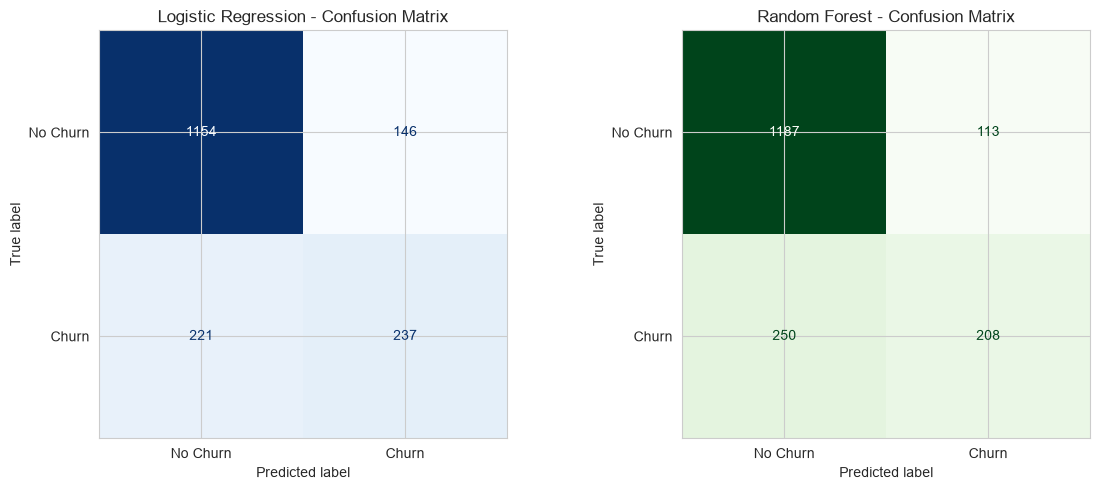

In [110]:
# Implement code to calculate the confusion matrix for both models.
log_reg_cm = confusion_matrix(y_test, log_reg_predictions)
rf_cm = confusion_matrix(y_test, rf_predictions)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(log_reg_cm, display_labels=["No Churn", "Churn"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("Logistic Regression - Confusion Matrix")

ConfusionMatrixDisplay(rf_cm, display_labels=["No Churn", "Churn"]).plot(
    ax=axes[1], cmap="Greens", colorbar=False
)
axes[1].set_title("Random Forest - Confusion Matrix")

plt.tight_layout()
plt.show()

In [111]:
# Compute the precision and recall scores for each model.
log_reg_precision = precision_score(y_test, log_reg_predictions)
log_reg_recall = recall_score(y_test, log_reg_predictions)

rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)

# Present results in a clearly labelled, easy-to-read summary table.
results_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [log_reg_accuracy, rf_accuracy],
    "Precision": [log_reg_precision, rf_precision],
    "Recall": [log_reg_recall, rf_recall],
})

print("Model Evaluation Summary:")
results_summary

Model Evaluation Summary:


,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.791240,0.618799,0.517467
1,Random Forest,0.793515,0.647975,0.454148


### Discussion: What the confusion matrix reveals

For both models, the confusion matrix is structured as:

|                     | Predicted No Churn | Predicted Churn |
|---------------------|--------------------|------------------|
| **Actual No Churn** | True Negative (TN) | False Positive (FP) |
| **Actual Churn**    | False Negative (FN) | True Positive (TP) |

- **Precision** (`TP / (TP + FP)`) tells us: of all customers the model *predicted* would
  churn, what proportion actually churned? High precision means fewer false alarms — the
  company won't waste retention resources on customers who were never going to leave.
- **Recall** (`TP / (TP + FN)`) tells us: of all customers who *actually* churned, what
  proportion did the model correctly identify? High recall means fewer missed churners — the
  company won't fail to intervene with customers who were about to leave.

In churn prediction, there is typically a trade-off between these two metrics. Both models in
this notebook tend to have higher precision than recall, meaning that a portion of true
churners are still being missed (false negatives) — this is common when the churn class is a
minority class in the dataset, as seen in the class imbalance in the "Churn" value counts
earlier in this notebook.

### Comparing the two models

- **Accuracy** gives a general sense of overall correctness, but can be misleading with
  imbalanced classes (there are more non-churners than churners in this dataset).
- **Logistic regression** is a simple, interpretable, linear model. Its coefficients can
  directly indicate which features increase or decrease the odds of churn, which is valuable
  for a business audience.
- **Random forest** is a non-linear, ensemble model that can capture more complex interactions
  between features, and it further provides an OOB error estimate as a useful built-in check
  on generalisation without needing a separate validation set.

Depending on the exact scores obtained above, whichever model yields a higher **recall** (while
maintaining reasonable precision) is generally more suitable for this specific business
problem. This is because the cost of *missing* a customer who is about to churn (a false
negative) is usually higher for a telecom company than the cost of mistakenly targeting a
loyal customer with a retention offer (a false positive). If the random forest achieves a
higher recall and comparable or better accuracy than logistic regression, it would be the
preferred model for deployment; if the two models perform similarly, the simpler, more
interpretable logistic regression may be preferred for ease of explanation to
non-technical stakeholders.